In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/3
    print("準備完了！このまま下のセルを実行できます。")

# 第3章 基本分布 (Standard Distributions)
## 3.3 周期変数 (Periodic Variables) とフォン・ミーゼス分布 (von Mises Distribution)

---

### 目次
1. [周期変数の特徴と課題 (Motivations and Coordinate Invariance)](#sec_motivation)
2. [重心ベクトル法による平均方向の導出 (Figure 3.9)](#sec_figure_3_9)
3. [周期確率密度の3公理](#sec_axioms)
4. [2次元ガウス分布からのフォン・ミーゼス分布の厳密幾何学的導出 (Figure 3.10)](#sec_figure_3_10)
5. [変形ベッセル関数 $I_0(m)$ と分布の可視化 (Figure 3.11)](#sec_figure_3_11)
6. [最尤推定 (MLE: Maximum Likelihood Estimation) の厳密導出](#sec_mle)
7. [ベッセル関数比率 $A(m)$ とパラメータ推定 (Figure 3.12)](#sec_figure_3_12)
8. [大 $m$ におけるガウス分布近似の検証](#sec_gaussian_limit)
9. [発展: 混合フォン・ミーゼスモデルと代替手法 (Mixtures & Wrapped Distributions)](#sec_advanced)
10. [理解度セルフチェックテスト (Assertions)](#sec_self_check)

---

### 本節の目標と位置づけ
『深層学習：基礎と概念』(Bishop & Bishop 2024) 第3章3節では、風向、時計の針、年間サイクル、分子の二面角（トーション角）などに代表される **周期変数 (Periodic Variables)** を扱うための確率モデリング手法を学びます。

通常の連続確率分布（ガウス分布など）をそのまま周期変数に適用すると、**座標原点の選び方に結果が著しく依存してしまう**という重大な欠陥が生じます。本節では、2次元ユークリッド空間上の単位円を用いた幾何学的アプローチから出発し、周期変数の代表的分布である **フォン・ミーゼス分布 (von Mises distribution / circular normal)** を数学的・直感的に厳密に導出・実装します。


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import special, integrate
from scipy.optimize import root_scalar

# ルートディレクトリの common モジュールをインポート可能にする
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from common.plot_utils import setup_style
from common.probability import (
    VonMisesDistribution,
    plot_figure_3_9,
    plot_figure_3_10,
    plot_figure_3_11,
    plot_figure_3_12
)

# ディレクトリに応じた安全な保存パスヘルパー
def get_save_paths(filename):
    if os.path.basename(os.getcwd()) == '3':
        return [f"result/{filename}", f"../result/{filename}"]
    else:
        return [f"3/result/{filename}", f"result/{filename}"]

setup_style()
print("Libraries and common modules loaded successfully.")


Libraries and common modules loaded successfully.


<a id="sec_motivation"></a>
### 1. 周期変数の特徴と課題 (Motivations and Coordinate Invariance)

実世界の多くのデータは、周期性をもつ角度パラメータ $\theta \in [0, 2\pi)$ として表現されます：
- ある地理的地点における**風向**
- 24時間の**時刻**（23:59 と 00:01 は2分しか離れていない）
- 1年の**日付**（12月31日 と 1月1日）
- タンパク質立体構造における**主鎖二面角** (Ramachandran angles $\phi, \psi$)

#### 座標原点依存性の破綻（教科書の具体例）
周期変数を通常の直線上のガウス分布 $\mathcal{N}(\mu, \sigma^2)$ でモデリングしようとした場合、座標原点の任意の選択によって統計量が全く変わってしまうという深刻な問題が発生します。

例えば、観測値が次の2点であるとします：
$$
\theta_1 = 1^\circ, \quad \theta_2 = 359^\circ
$$
直感的には、これら2点は角度としてわずか $2^\circ$ しか離れておらず、その平均は $0^\circ$（または $360^\circ$）であるべきです。

しかし、単純な算術平均を適用すると：
1. **原点を $0^\circ$ に置いた場合**:
   $$
   \bar{\theta} = \frac{1^\circ + 359^\circ}{2} = 180^\circ, \quad \text{標準偏差} \approx 179^\circ
   $$
   （全くデータが存在しない反対側の $180^\circ$ が平均と推定され、散らばりも極大と誤認される！）
2. **原点を $180^\circ$ に置いた場合**（角度を $[-180^\circ, +180^\circ)$ で表現）:
   $\theta_1 = +1^\circ$, $\theta_2 = -1^\circ$ となり、
   $$
   \bar{\theta} = \frac{1^\circ + (-1^\circ)}{2} = 0^\circ, \quad \text{標準偏差} = 1^\circ
   $$
   （正しく $0^\circ$ が平均と推定される）

このように、**原点の決め方次第で平均が $180^\circ$ も乖離してしまう**ため、直線上の通常平均は周期変数には全く適しません。


In [2]:
# 通常の算術平均における原点依存性の数値検証
th1_deg, th2_deg = 1.0, 359.0

# 1. 範囲 [0, 360) での算術平均
naive_mean = (th1_deg + th2_deg) / 2.0
naive_std = np.std([th1_deg, th2_deg], ddof=1)
print(f"[範囲 0~360度] 算術平均: {naive_mean:.1f}度, 標本標準偏差: {naive_std:.1f}度 (破綻)")

# 2. 範囲 [-180, 180) での算術平均
th2_shifted = th2_deg - 360.0  # -1度
shifted_mean = (th1_deg + th2_shifted) / 2.0
shifted_std = np.std([th1_deg, th2_shifted], ddof=1)
print(f"[範囲 -180~180度] 算術平均: {shifted_mean:.1f}度, 標本標準偏差: {shifted_std:.1f}度 (正常)")

# 3. 周期性を考慮した円周平均 (Circular Mean)
circ_mean_rad = VonMisesDistribution.circular_mean(np.radians([th1_deg, th2_deg]))
print(f"[共通モジュール] 円周平均: {np.degrees(circ_mean_rad):.1f}度 (原点非依存・不変)")


[範囲 0~360度] 算術平均: 180.0度, 標本標準偏差: 253.1度 (破綻)
[範囲 -180~180度] 算術平均: 0.0度, 標本標準偏差: 1.4度 (正常)
[共通モジュール] 円周平均: 360.0度 (原点非依存・不変)


<a id="sec_figure_3_9"></a>
### 2. 重心ベクトル法による平均方向の導出 (Figure 3.9)

座標原点に依存しない平均角度を定義するため、教科書では **各角度観測値 $\theta_n$ を2次元単位円上のベクトル $\mathbf{x}_n$ とみなす** アプローチを採用します（Figure 3.9）。

#### 1. ベクトルのデカルト座標表現
各観測値 $\theta_n$ ($n = 1, \dots, N$) は、ノルム $\|\mathbf{x}_n\| = 1$ の2次元単位ベクトルとして表されます：
$$
\mathbf{x}_n = \begin{pmatrix} \cos \theta_n \\ \sin \theta_n \end{pmatrix}
$$

#### 2. 重心ベクトル $\bar{\mathbf{x}}$ の計算
$N$ 個の単位ベクトルの算術平均をとると、平均ベクトル $\bar{\mathbf{x}}$ が得られます（式 3.117）：
$$
\bar{\mathbf{x}} = \frac{1}{N} \sum_{n=1}^N \mathbf{x}_n \tag{3.117}
$$
この平均ベクトル $\bar{\mathbf{x}}$ は一般に単位円の内部（または面上）に位置します（$\|ar{\mathbf{x}}\| \le 1$）。

#### 3. 極座標表現との同定
$\bar{\mathbf{x}}$ を極座標 $(r, \bar{\theta})$ で表現します：
$$
\bar{\mathbf{x}} = \begin{pmatrix} r \cos \bar{\theta} \\ r \sin \bar{\theta} \end{pmatrix}
$$
各成分を比較すると（式 3.118）：
$$
r \cos \bar{\theta} = \frac{1}{N} \sum_{n=1}^N \cos \theta_n \tag{3.118a}
$$
$$
r \sin \bar{\theta} = \frac{1}{N} \sum_{n=1}^N \sin \theta_n \tag{3.118b}
$$

両式の比をとると、$r$ が相殺され：
$$
\tan \bar{\theta} = \frac{\sum_{n=1}^N \sin \theta_n}{\sum_{n=1}^N \cos \theta_n}
$$
したがって、平均角度 $\bar{\theta}$ は次のように求まります（式 3.119）：
$$
\bar{\theta} = \text{atan2} \left( \sum_{n=1}^N \sin \theta_n, \; \sum_{n=1}^N \cos \theta_n \right) \tag{3.119}
$$

また、平均ベクトルの長さ $r \in [0, 1]$ は **合成ベクトルの長さ (mean resultant length $\bar{R}$)** と呼ばれ、角度の集中度（散らばりの逆）を表します：
- データが1つの方向に密集しているとき: $\bar{R} \approx 1$
- データが全方向に均等に散らばっているとき: $\bar{R} \approx 0$
- **円周分散 (Circular Variance)**: $V = 1 - \bar{R} \in [0, 1]$


Figure 3.9 saved successfully to: result/fig3_09_periodic_vectors.png


Figure 3.9 saved successfully to: ../result/fig3_09_periodic_vectors.png


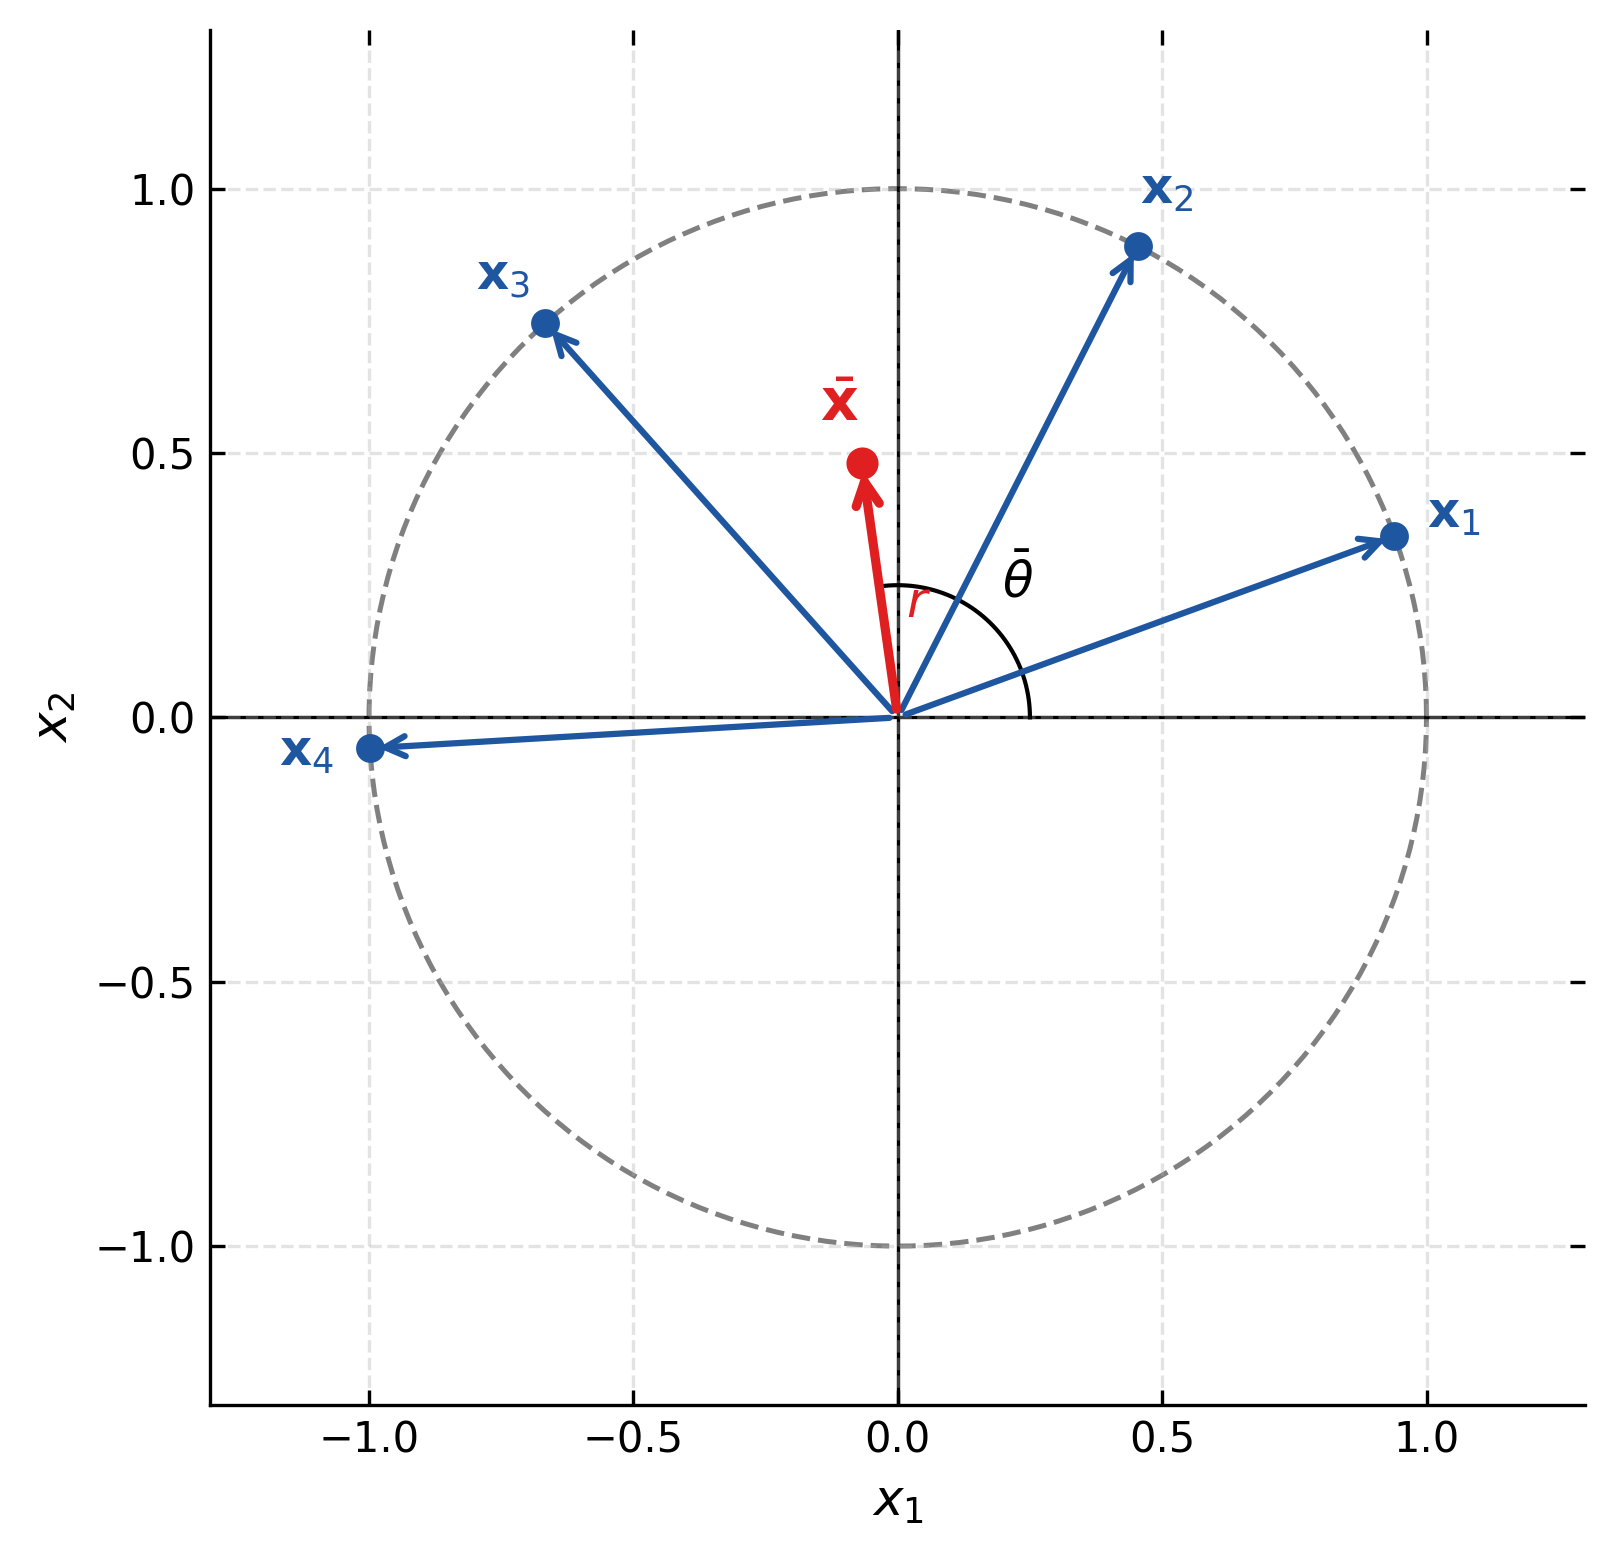

In [3]:
# 教科書 Figure 3.9 の完全再現: 単位円上のベクトルとその平均
fig3_9, ax3_9 = plot_figure_3_9(
    save_paths=get_save_paths('fig3_09_periodic_vectors.png'),
    show=True
)


<a id="sec_axioms"></a>
### 3. 周期確率密度の3公理

周期変数 $\theta$（周期 $2\pi$）に対する任意の確率密度関数 $p(\theta)$ が満たすべき数学的性質は、次の3つの公理によって規定されます：

1. **非負性 (Non-negativity)**:
   $$
   p(\theta) \ge 0 \tag{3.120}
   $$
2. **全確率正規化 (Normalization)**:
   $$
   \int_0^{2\pi} p(\theta) d\theta = 1 \tag{3.121}
   $$
3. **周期性 (Periodicity)**:
   $$
   p(\theta + 2\pi) = p(\theta) \tag{3.122}
   $$

この周期性から、任意の整数 $M \in \mathbb{Z}$ に対して $p(\theta + 2\pi M) = p(\theta)$ が成立します。


<a id="sec_figure_3_10"></a>
### 4. 2次元ガウス分布からのフォン・ミーゼス分布の厳密幾何学的導出 (Figure 3.10)

ガウス分布の自然な周期版を構成する極めて洗練された方法が、**2次元等方性ガウス分布を単位円 $r=1$ 上へ条件付ける（制限する）** という幾何学的アプローチです（Figure 3.10）。

#### ステップ 1: 2次元等方性ガウス分布の定義
2次元空間 $\mathbf{x} = (x_1, x_2)^T$ 上で、平均 $\boldsymbol{\mu} = (\mu_1, \mu_2)^T$、共分散行列 $\boldsymbol{\Sigma} = \sigma^2 \mathbf{I}$ のガウス分布を考えます（式 3.123）：
$$
p(x_1, x_2) = \frac{1}{2\pi \sigma^2} \exp \left( -\frac{(x_1 - \mu_1)^2 + (x_2 - \mu_2)^2}{2\sigma^2} \right) \tag{3.123}
$$
この等高線は、$\boldsymbol{\mu}$ を中心とする同心円となります。

#### ステップ 2: 極座標変換
変数 $(x_1, x_2)$ および平均パラメータ $(\mu_1, \mu_2)$ を極座標系へ変換します（式 3.124, 3.125）：
$$
x_1 = r \cos \theta, \quad x_2 = r \sin \theta \tag{3.124}
$$
$$
\mu_1 = r_0 \cos \theta_0, \quad \mu_2 = r_0 \sin \theta_0 \tag{3.125}
$$

#### ステップ 3: 指数部への代入と単位円 $r=1$ への制限
指数部を展開し、単位円 $r = 1$ に制限します：
$$
-\frac{1}{2\sigma^2} \left[ (r \cos \theta - r_0 \cos \theta_0)^2 + (r \sin \theta - r_0 \sin \theta_0)^2 \right]
$$
$$
= -\frac{1}{2\sigma^2} \left[ r^2 (\cos^2 \theta + \sin^2 \theta) + r_0^2 (\cos^2 \theta_0 + \sin^2 \theta_0) - 2 r r_0 (\cos \theta \cos \theta_0 + \sin \theta \sin \theta_0) \right]
$$

三角関数の加法定理と恒等式：
$$
\cos^2 A + \sin^2 A = 1 \tag{3.127}
$$
$$
\cos A \cos B + \sin A \sin B = \cos(A - B) \tag{3.128}
$$
を用いると：
$$
= -\frac{1}{2\sigma^2} \left[ r^2 + r_0^2 - 2 r r_0 \cos(\theta - \theta_0) \right]
$$

$r=1$ を代入すると：
$$
= -\frac{1 + r_0^2}{2\sigma^2} + \frac{r_0}{\sigma^2} \cos(\theta - \theta_0) \tag{3.126}
$$
第1項は $\theta$ に依存しない定数項（const）であるため、指数関数を分解すると：
$$
p(\theta) \propto \exp \left( \frac{r_0}{\sigma^2} \cos(\theta - \theta_0) \right)
$$

#### ステップ 4: パラメータ $m$ の定義とフォン・ミーゼス分布の形
集中度パラメータ $m$ を次のように定義します：
$$
m \equiv \frac{r_0}{\sigma^2}
$$
これにより、単位円上の密度は次のように表されます（式 3.129）：
$$
p(\theta | \theta_0, m) = \frac{1}{2\pi I_0(m)} \exp \left( m \cos(\theta - \theta_0) \right) \tag{3.129}
$$
これが **フォン・ミーゼス分布 (von Mises distribution / circular normal)** です！


Figure 3.10 saved successfully to: result/fig3_10_von_mises_conditioning.png
Figure 3.10 saved successfully to: ../result/fig3_10_von_mises_conditioning.png


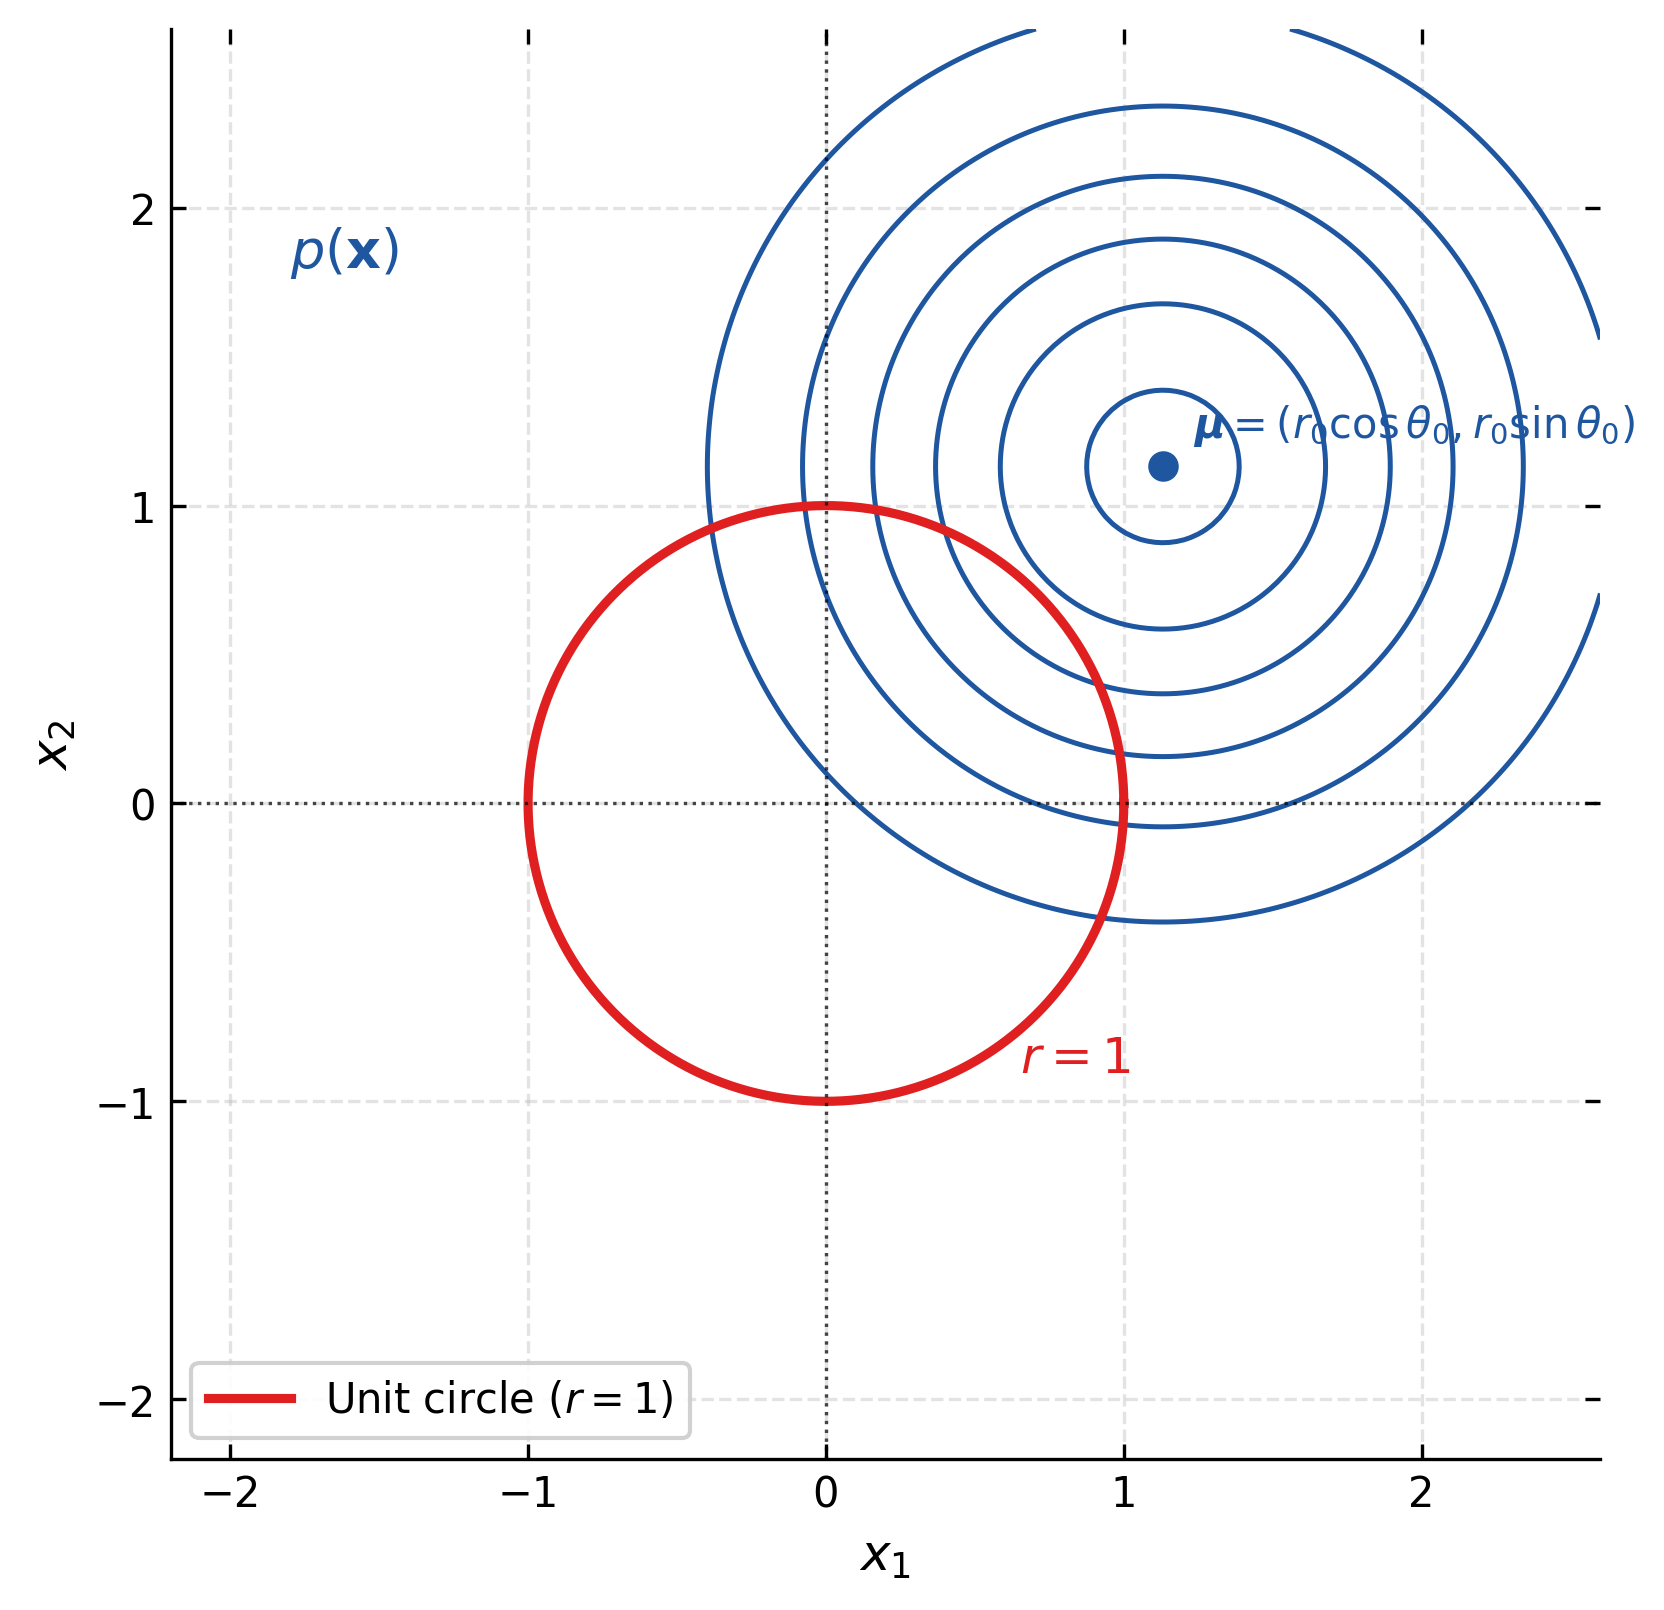

In [4]:
# 教科書 Figure 3.10 の完全再現: 2次元ガウス分布の単位円への条件付け
fig3_10, ax3_10 = plot_figure_3_10(
    save_paths=get_save_paths('fig3_10_von_mises_conditioning.png'),
    show=True
)


<a id="sec_figure_3_11"></a>
### 5. 変形ベッセル関数 $I_0(m)$ と分布の可視化 (Figure 3.11)

#### 1. 正規化定数と第1種0次変形ベッセル関数
分布 $p(\theta | \theta_0, m)$ の全積分を 1 にするための正規化定数は：
$$
\int_0^{2\pi} \exp(m \cos(\theta - \theta_0)) d\theta = \int_0^{2\pi} \exp(m \cos \theta) d\theta = 2\pi I_0(m)
$$
ここで登場する $I_0(m)$ が **第1種0次変形ベッセル関数 (zeroth-order modified Bessel function of the first kind)** です（式 3.130）：
$$
I_0(m) = \frac{1}{2\pi} \int_0^{2\pi} \exp(m \cos \theta) d\theta \tag{3.130}
$$

その級数展開表示は次の通りです：
$$
I_0(m) = \sum_{k=0}^\infty \frac{1}{(k!)^2} \left( \frac{m}{2} \right)^{2k} = 1 + \frac{m^2}{4} + \frac{m^4}{64} + \cdots
$$
- $m = 0$ のとき: $I_0(0) = 1$ となり、$p(\theta | \theta_0, 0) = \frac{1}{2\pi}$（一様分布）
- $m > 0$ のとき: $m$ が大きくなるほど $\theta_0$ の周りに急峻に尖る分布となる

#### 2. 直交座標プロットと極座標プロット (Figure 3.11)
教科書 Figure 3.11 では、2組のパラメータについて可視化しています：
1. $m = 5, \theta_0 = \pi/4$ (赤線): 鋭い単峰性の分布
2. $m = 1, \theta_0 = 3\pi/4$ (青線): なだらかな単峰性の分布


Figure 3.11 saved successfully to: result/fig3_11_von_mises_distribution.png
Figure 3.11 saved successfully to: ../result/fig3_11_von_mises_distribution.png


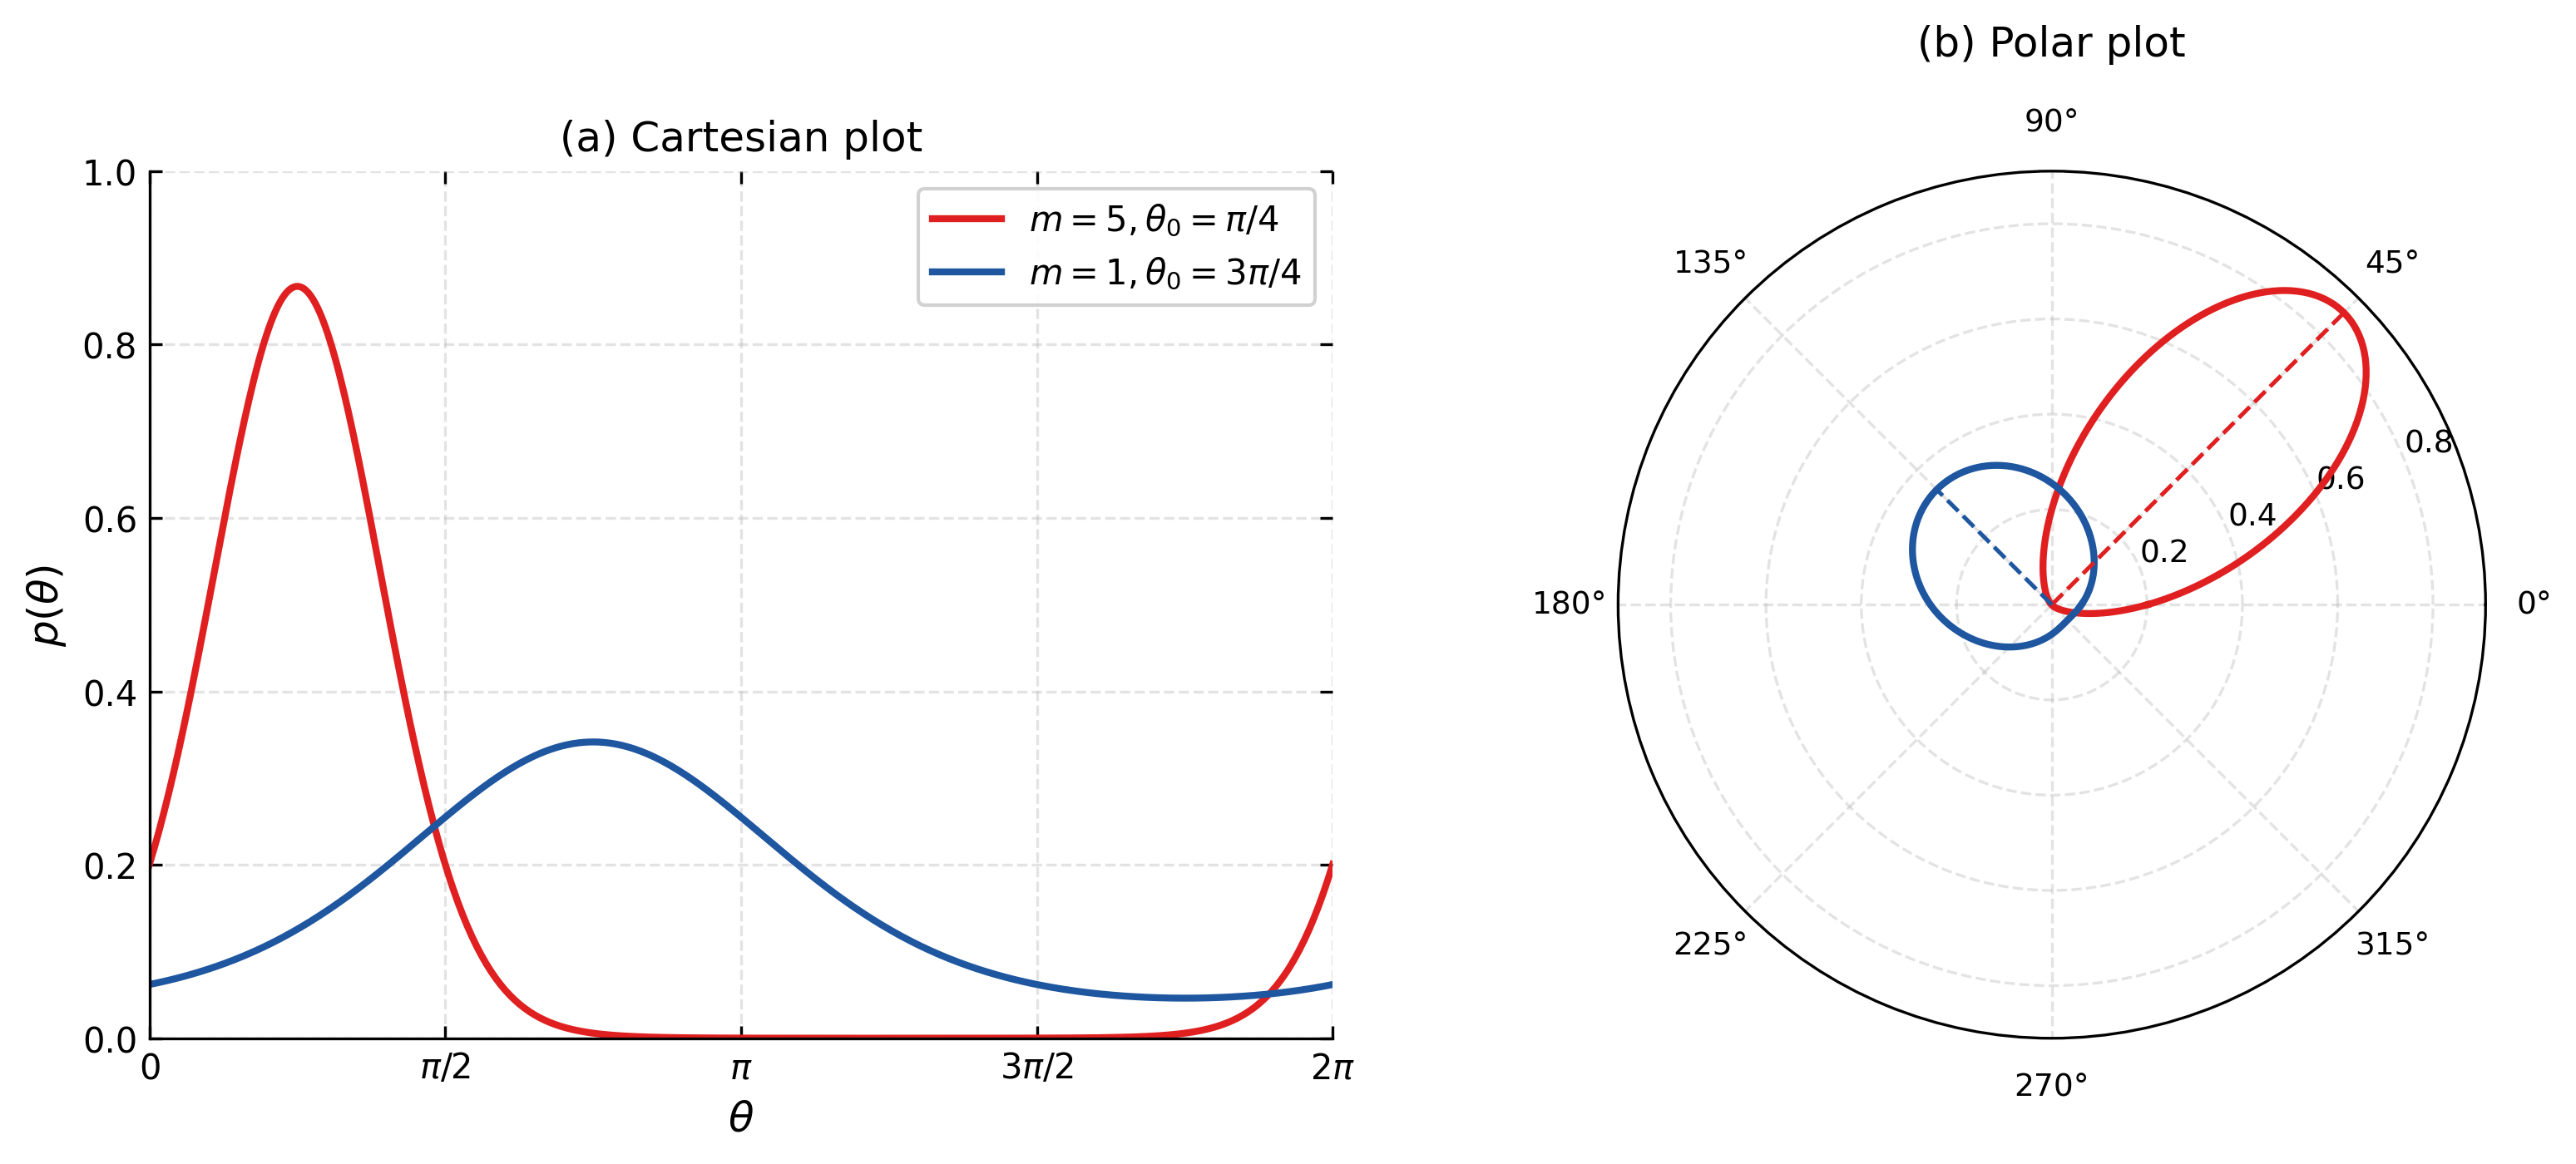

In [5]:
# 教科書 Figure 3.11 の完全再現: フォン・ミーゼス分布 (Cartesian & Polar)
fig3_11, (ax3_11_1, ax3_11_2) = plot_figure_3_11(
    save_paths=get_save_paths('fig3_11_von_mises_distribution.png'),
    show=True
)


<a id="sec_mle"></a>
### 6. 最尤推定 (MLE: Maximum Likelihood Estimation) の厳密導出

観測データ $\mathcal{D} = \{\theta_1, \dots, \theta_N\}$ が与えられたとき、パラメータ $\theta_0$ および $m$ の最尤解を求めます。

#### 1. 対数尤度関数の構築
観測値が独立同分布 (i.i.d.) であると仮定すると、尤度関数は各点密度の積となります：
$$
p(\mathcal{D} | \theta_0, m) = \prod_{n=1}^N \frac{1}{2\pi I_0(m)} \exp \left( m \cos(\theta_n - \theta_0) \right)
$$
両辺の対数をとると、対数尤度関数 $\ln p(\mathcal{D} | \theta_0, m)$ は次のようになります（式 3.131）：
$$
\ln p(\mathcal{D} | \theta_0, m) = -N \ln(2\pi) - N \ln I_0(m) + m \sum_{n=1}^N \cos(\theta_n - \theta_0) \tag{3.131}
$$

---

#### 2. 平均角度 $\theta_0$ の最尤推定値 $\theta_0^{\text{ML}}$ の導出
対数尤度を $\theta_0$ で偏微分し、ゼロとおきます：
$$
\frac{\partial}{\partial \theta_0} \ln p(\mathcal{D} | \theta_0, m) = m \sum_{n=1}^N \sin(\theta_n - \theta_0) = 0 \tag{3.132}
$$
$m > 0$ であるため、次式が得られます：
$$
\sum_{n=1}^N \sin(\theta_n - \theta_0) = 0
$$

三角関数の加法定理 $\sin(A - B) = \sin A \cos B - \cos A \sin B$（式 3.133）を適用すると：
$$
\sum_{n=1}^N [\sin \theta_n \cos \theta_0 - \cos \theta_n \sin \theta_0] = 0
$$
$$
\cos \theta_0 \sum_{n=1}^N \sin \theta_n = \sin \theta_0 \sum_{n=1}^N \cos \theta_n
$$
両辺を $\cos \theta_0 \sum_{n=1}^N \cos \theta_n$ で割ると：
$$
\tan \theta_0 = \frac{\sum_{n=1}^N \sin \theta_n}{\sum_{n=1}^N \cos \theta_n}
$$
したがって、最尤解 $\theta_0^{\text{ML}}$ は次式で与えられます（式 3.134）：
$$
\theta_0^{\text{ML}} = \text{atan2} \left( \sum_{n=1}^N \sin \theta_n, \; \sum_{n=1}^N \cos \theta_n \right) \tag{3.134}
$$
これは、冒頭の単位円上の重心ベクトル法（式 3.119）と**数学的に完全に一致**します！


<a id="sec_figure_3_12"></a>
### 7. ベッセル関数比率 $A(m)$ とパラメータ推定 (Figure 3.12)

#### 1. 集中度パラメータ $m$ の最尤解 $m^{\text{ML}}$ の導出
次に、対数尤度関数（式 3.131）を $m$ で偏微分します：
$$
\frac{\partial}{\partial m} \ln p(\mathcal{D} | \theta_0, m) = -N \frac{I_0'(m)}{I_0(m)} + \sum_{n=1}^N \cos(\theta_n - \theta_0) = 0
$$

ここで、変形ベッセル関数の微分に関する公式 $I_0'(m) = I_1(m)$（ここで $I_1(m)$ は第1種1次変形ベッセル関数）を用いると：
$$
\frac{I_1(m)}{I_0(m)} = \frac{1}{N} \sum_{n=1}^N \cos(\theta_n - \theta_0^{\text{ML}}) \tag{3.135}
$$

比率関数 $A(m)$ を次のように定義します（式 3.136）：
$$
A(m) \equiv \frac{I_1(m)}{I_0(m)} \tag{3.136}
$$

#### 2. 合成ベクトル長 $\bar{R}$ との関係
右辺の和は、加法定理により次のように書き換えられます（式 3.137）：
$$
\frac{1}{N} \sum_{n=1}^N \cos(\theta_n - \theta_0^{\text{ML}}) = \left( \frac{1}{N} \sum_{n=1}^N \cos \theta_n \right) \cos \theta_0^{\text{ML}} + \left( \frac{1}{N} \sum_{n=1}^N \sin \theta_n \right) \sin \theta_0^{\text{ML}} = \bar{R} \tag{3.137}
$$
すなわち：
$$
A(m^{\text{ML}}) = \bar{R}
$$
ここで $\bar{R} = \|\bar{\mathbf{x}}\| \in [0, 1]$ は観測データの合成ベクトル長です。

#### 3. 数値反転アルゴリズム
$A(m)$ は $m \ge 0$ において単調増加関数であり、$A(0) = 0$、$\lim_{m \to \infty} A(m) = 1$ を満たします（Figure 3.12）。したがって、与えられた $\bar{R}$ に対する $m^{\text{ML}} = A^{-1}(\bar{R})$ は一意に定まります。
- Mardia & Jupp (2000) による高精度初期近似：
  $$
  m_0 = \begin{cases}
  2\bar{R} + \bar{R}^3 + \frac{5}{6}\bar{R}^5 & (\bar{R} < 0.53) \\
  -0.4 + 1.39\bar{R} + \frac{0.43}{1 - \bar{R}} & (0.53 \le \bar{R} < 0.85) \\
  \frac{1}{\bar{R}^3 - 4\bar{R}^2 + 3\bar{R}} & (\bar{R} \ge 0.85)
  \end{cases}
  $$
- その後、Brent法等の1次元求根アルゴリズム（`root_scalar`）で厳密解を求めます。


Figure 3.12 saved successfully to: result/fig3_12_bessel_and_A_functions.png
Figure 3.12 saved successfully to: ../result/fig3_12_bessel_and_A_functions.png


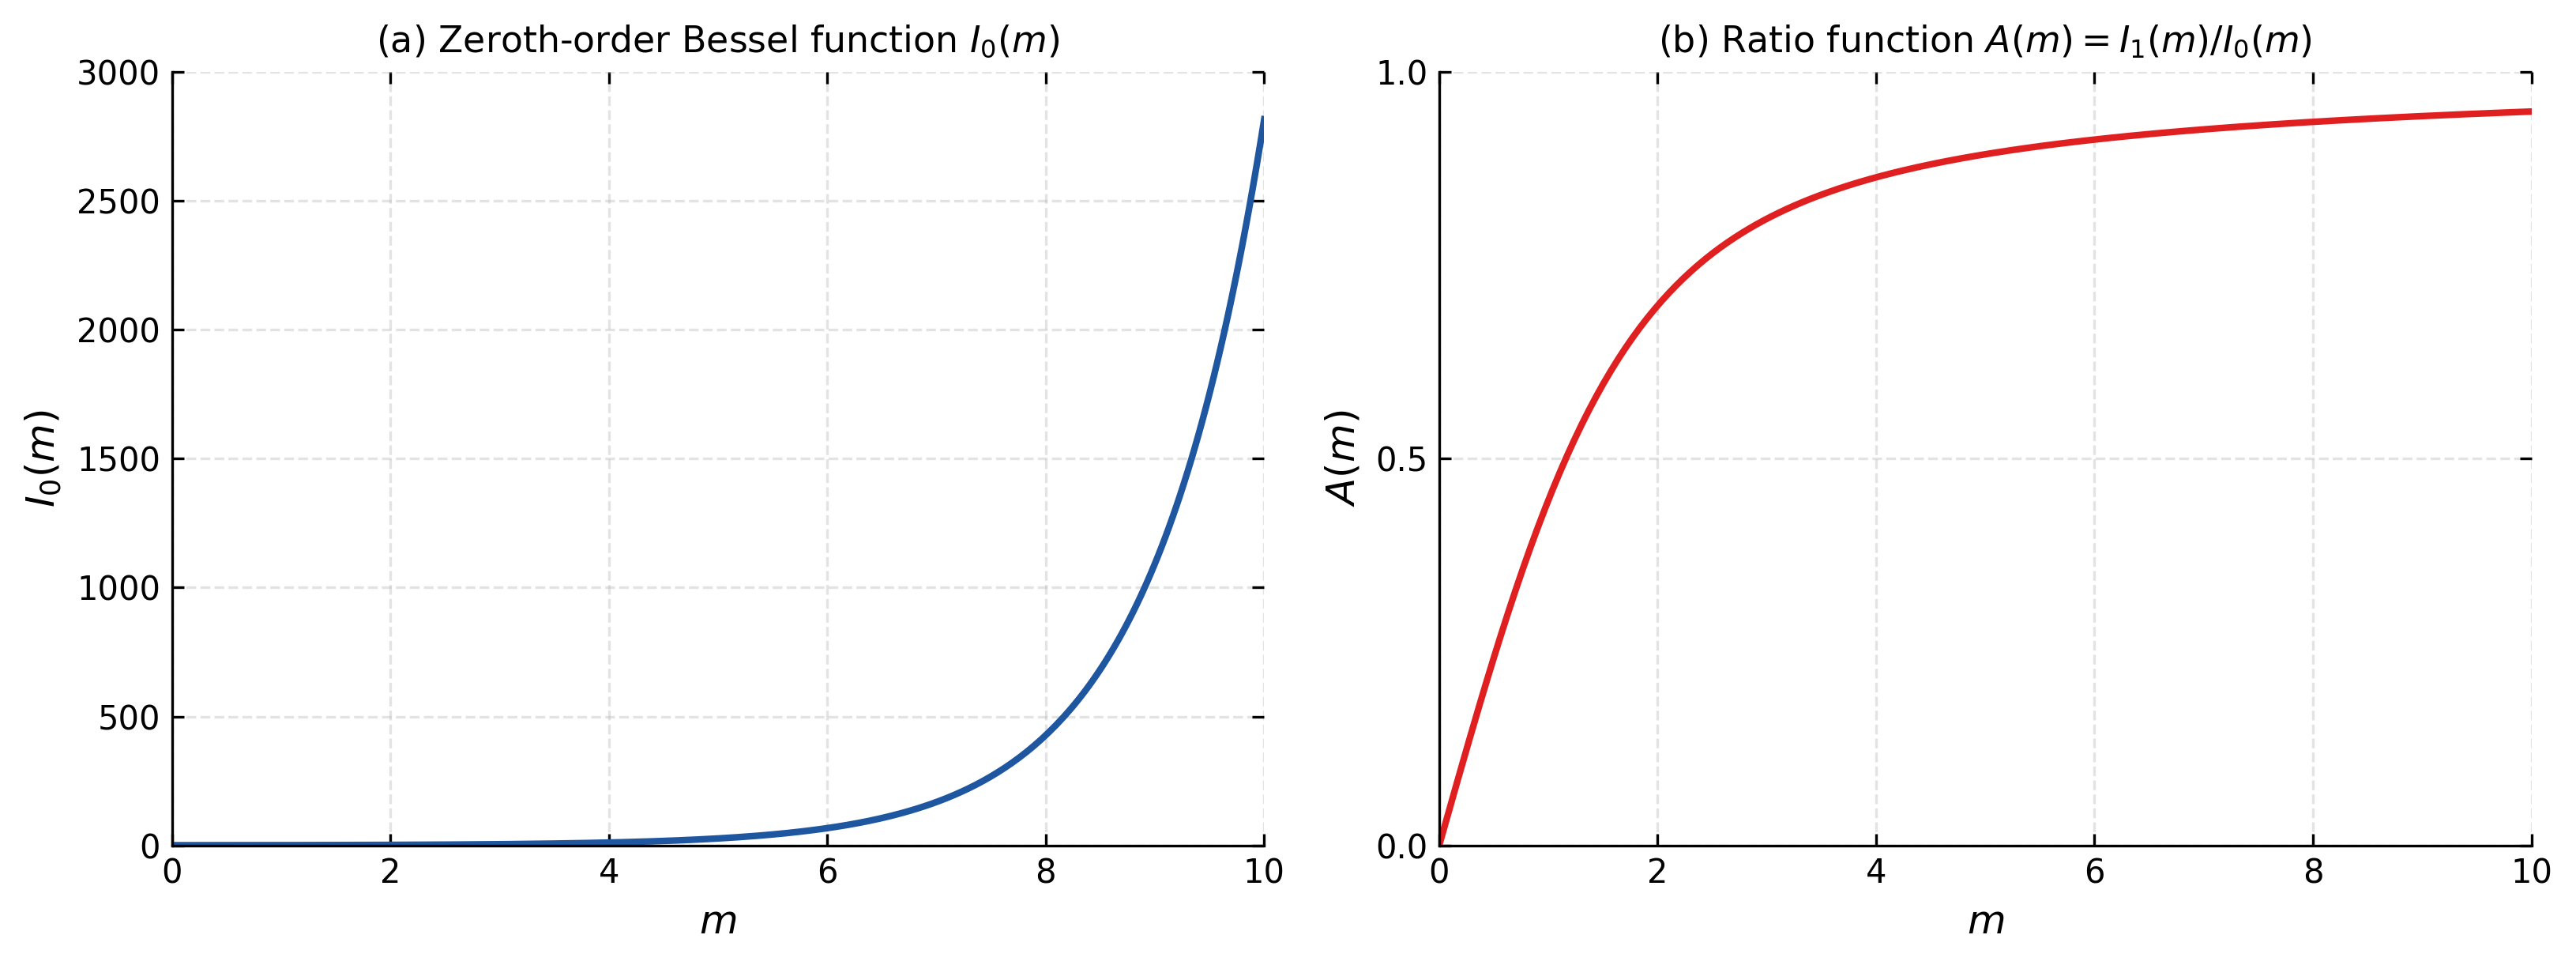

In [6]:
# 教科書 Figure 3.12 の完全再現: ベッセル関数 I_0(m) と比率関数 A(m)
fig3_12, (ax3_12_1, ax3_12_2) = plot_figure_3_12(
    save_paths=get_save_paths('fig3_12_bessel_and_A_functions.png'),
    show=True
)


<a id="sec_gaussian_limit"></a>
### 8. 大 $m$ におけるガウス分布近似の検証

集中度パラメータ $m$ が大きいとき（$m \gg 1$）、フォン・ミーゼス分布は平均 $\theta_0$、分散 $\sigma^2 = 1/m$ のガウス分布に急速に漸近します。

#### 数学的導出
$\theta$ が $\theta_0$ に十分近い領域で、余弦関数を2次のテイラー展開します：
$$
\cos(\theta - \theta_0) \approx 1 - \frac{1}{2}(\theta - \theta_0)^2
$$
これを指数部に代入すると：
$$
\exp(m \cos(\theta - \theta_0)) \approx \exp(m) \exp \left( -\frac{m}{2}(\theta - \theta_0)^2 \right)
$$

また、大 $m$ における変形ベッセル関数の漸近展開（Abramowitz and Stegun 1965）は：
$$
I_0(m) \approx \frac{\exp(m)}{\sqrt{2\pi m}} \quad (m \to \infty)
$$
となります。これらを正規化された確率密度式に代入すると：
$$
p(\theta | \theta_0, m) = \frac{\exp(m \cos(\theta - \theta_0))}{2\pi I_0(m)} \approx \frac{\exp(m) \exp \left( -\frac{m}{2}(\theta - \theta_0)^2 \right)}{2\pi \cdot \frac{\exp(m)}{\sqrt{2\pi m}}} = \frac{1}{\sqrt{2\pi / m}} \exp \left( -\frac{(\theta - \theta_0)^2}{2(1/m)} \right)
$$
これはまさに平均 $\theta_0$、分散 $\sigma^2 = 1/m$（精度 $\lambda = m$）の1次元ガウス分布 $\mathcal{N}(\theta | \theta_0, 1/m)$ そのものです！


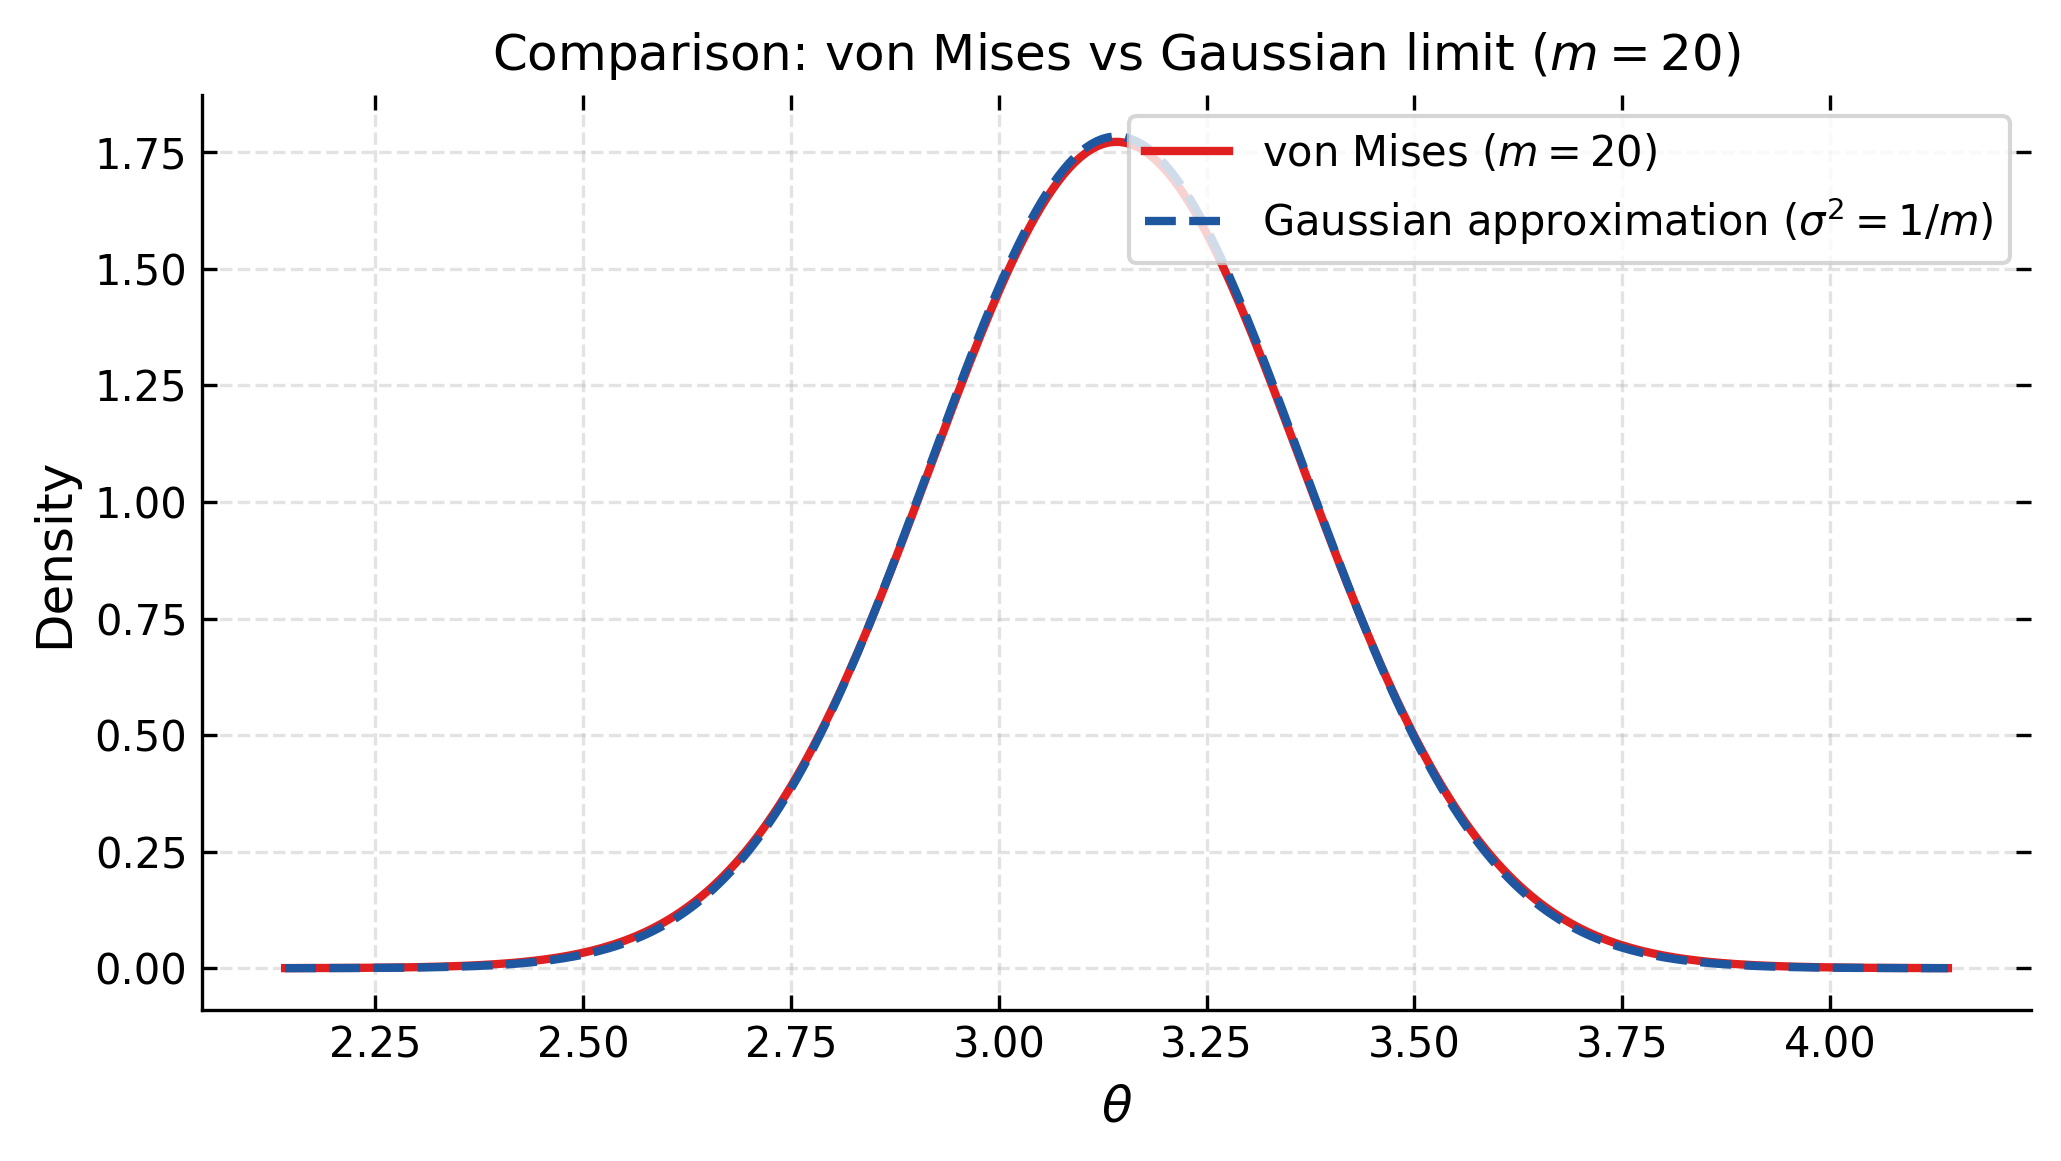

m = 20.0 における密度差の最大値: 0.01141


In [7]:
# 大 m におけるフォン・ミーゼス分布とガウス分布の一致度検証
m_test = 20.0
th0_test = np.pi

vm = VonMisesDistribution(theta_0=th0_test, m=m_test)
theta_grid = np.linspace(th0_test - 1.0, th0_test + 1.0, 300)

vm_vals = vm.pdf(theta_grid)

# 漸近ガウス分布 N(th0, 1/m)
sigma_gauss = 1.0 / np.sqrt(m_test)
gauss_vals = np.exp(-0.5 * ((theta_grid - th0_test) / sigma_gauss)**2) / (np.sqrt(2 * np.pi) * sigma_gauss)

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
ax.plot(theta_grid, vm_vals, label=f'von Mises ($m={m_test:.0f}$)', color='#E02020', linewidth=2.0)
ax.plot(theta_grid, gauss_vals, label=f'Gaussian approximation ($\\sigma^2=1/m$)', color='#1E56A0', linestyle='--', linewidth=2.0)
ax.set_xlabel(r'$\theta$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Comparison: von Mises vs Gaussian limit ($m={m_test:.0f}$)', fontsize=12)
ax.legend(loc='upper right', frameon=True)
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(vm_vals - gauss_vals))
print(f"m = {m_test} における密度差の最大値: {max_diff:.5f}")
assert max_diff < 0.05, "ガウス分布近似との誤差が想定内であることを確認"


<a id="sec_advanced"></a>
### 9. 発展: 混合フォン・ミーゼスモデルと代替手法 (Mixtures & Wrapped Distributions)

#### 1. 単峰性の限界と混合フォン・ミーゼス分布 (Mixture of von Mises)
フォン・ミーゼス分布は本質的に **単峰性 (unimodal)** です。しかし、風向データ（季節による二峰性風向）やタンパク質の二面角分布のように、周期変数が複数のピークを持つことは珍しくありません。

この限界を打破するため、第3章2節のガウス混合モデル (GMM) と同様に、$K$ 個のフォン・ミーゼス成分の線形結合による **混合フォン・ミーゼスモデル (Mixture of von Mises Distributions)** が利用されます：
$$
p(\theta) = \sum_{k=1}^K \pi_k \, p(\theta | \theta_{0k}, m_k)
$$
ここで $\pi_k \ge 0$, $\sum_{k=1}^K \pi_k = 1$ であり、パラメータ推定には第15章で詳解される EMアルゴリズムが直接適用可能です。

#### 2. 代替的な周期モデリング手法
教科書 p. 93-94 で言及されている代替アプローチ：
1. **角度ヒストグラム法**:
   円周 $[0, 2\pi)$ を $B$ 個のビンに分割し頻度をカウント。実装は極めて容易だが、ビンの境界選択や滑らかさの欠如が課題。
2. **2次元ガウス分布の周回積分 (Marginalization)**:
   条件付け（$r=1$）ではなく、動径方向 $r$ について積分消去（周辺化）する方法。解析的な形が複雑化する。
3. **ラップガウス分布 (Wrapped Gaussian Distribution)**:
   実数軸 $\mathbb{R}$ 上のガウス分布を $2\pi$ 周期で「巻き付ける」：
   $$
   p_{\text{wrapped}}(\theta) = \sum_{k=-\infty}^\infty \mathcal{N}(\theta + 2\pi k | \mu, \sigma^2)
   $$
   これも周期性を厳密に満たしますが、無限級数の和を含むため計算がやや煩雑となります。


--- フォン・ミーゼス最尤推定 (MLE) 結果 ---
真のパラメータ:   theta_0 = 1.8500 rad (106.00°), m = 3.5000
最尤推定値 (MLE): theta_0 = 1.8397 rad (105.41°), m = 3.6544
標本平均ベクトル長 r_bar: 0.8488
標本円周分散 V = 1 - r_bar: 0.1512


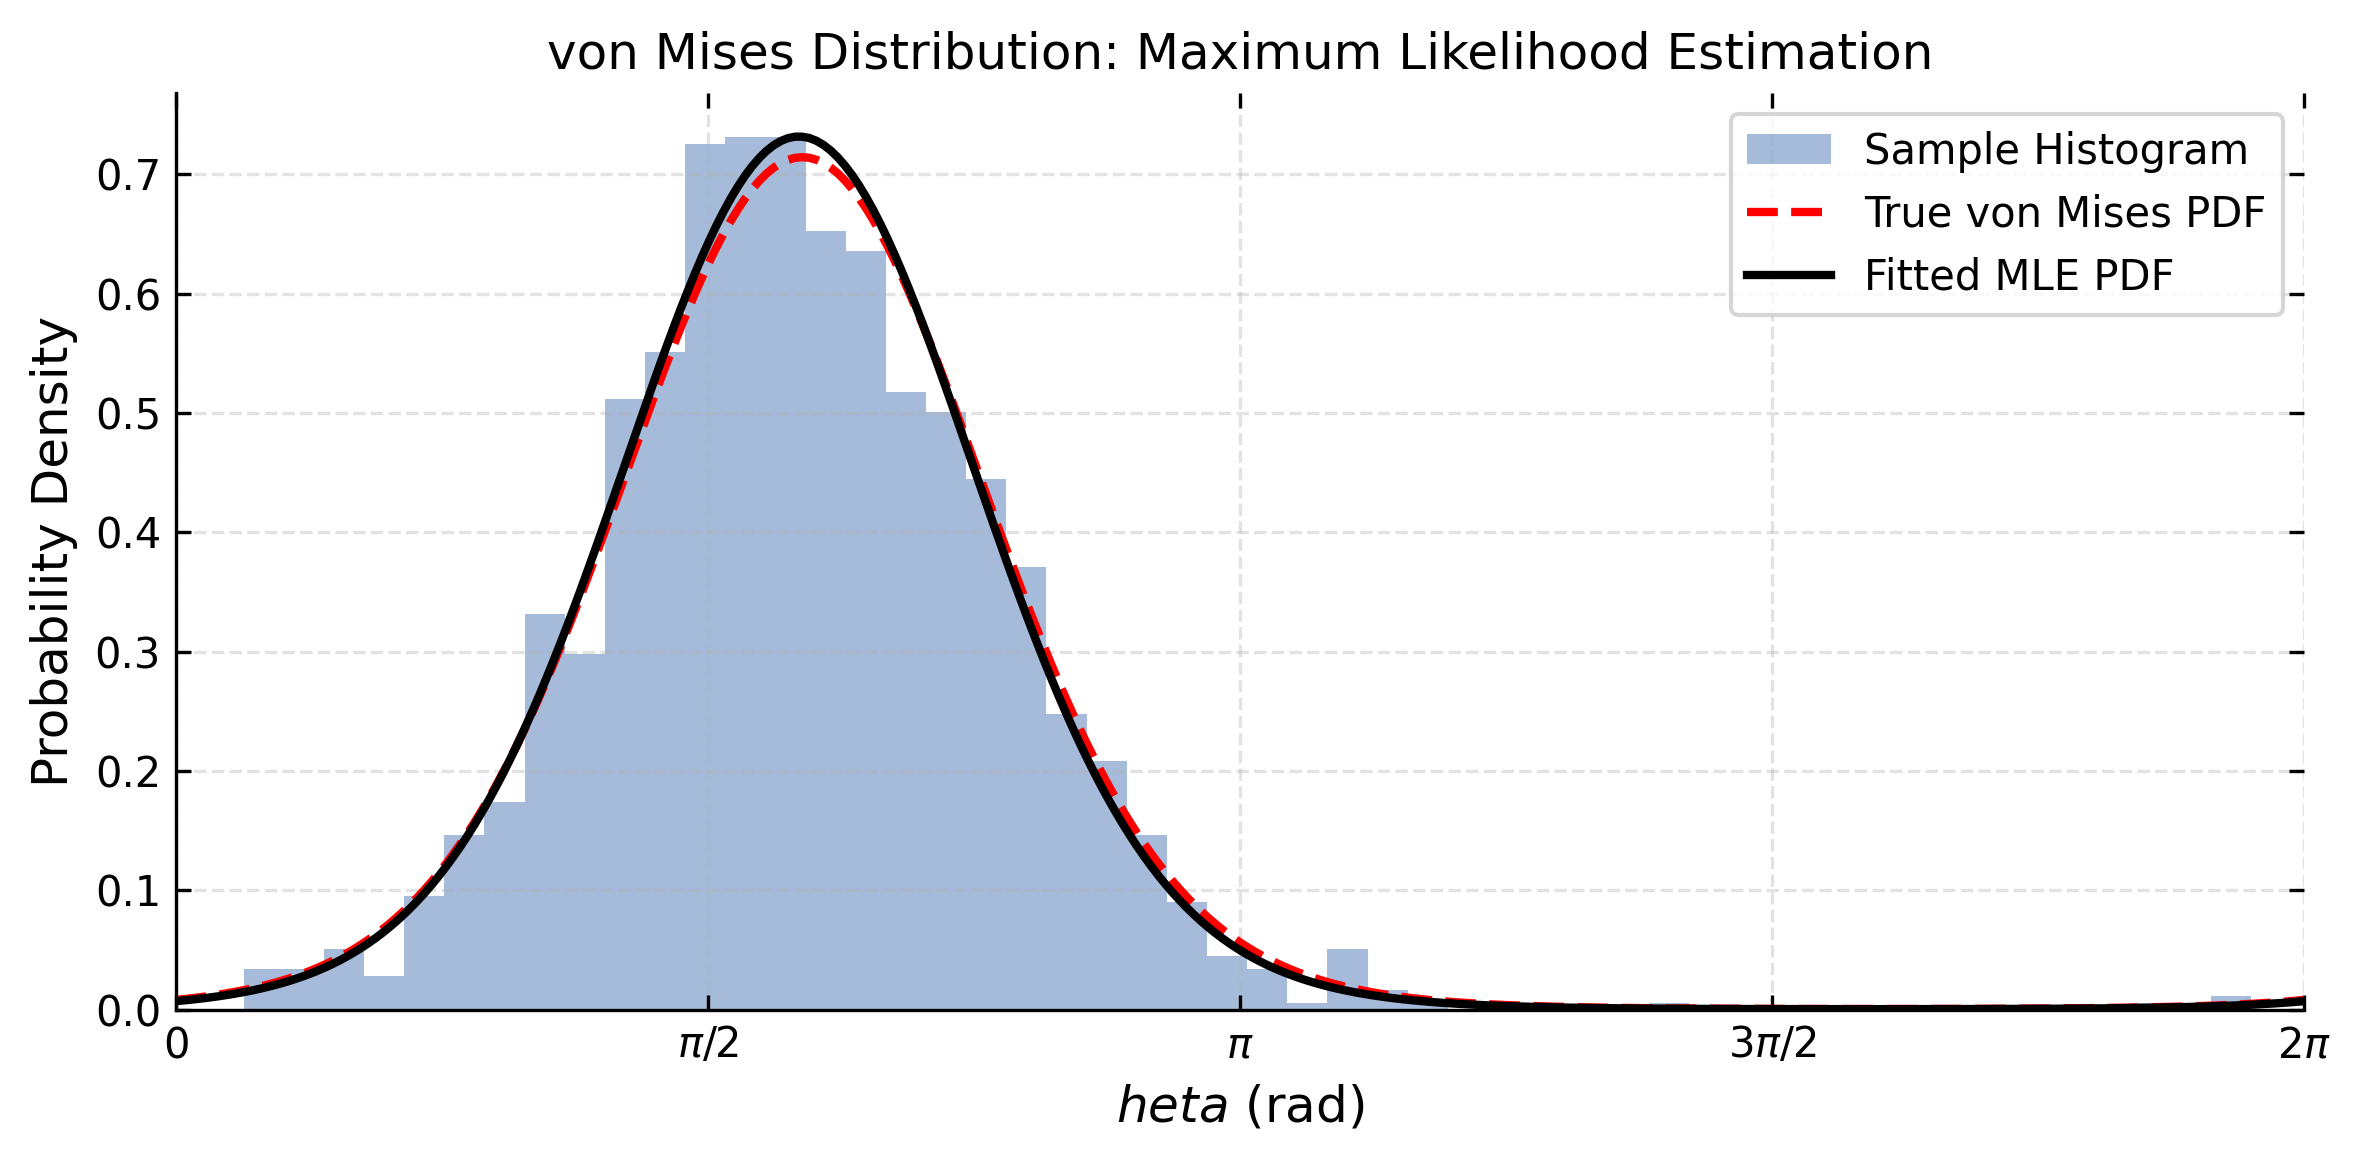

In [8]:
# 合成角度データに対する最尤推定 (MLE) の実行検証
np.random.seed(42)
true_theta0 = 1.85   # 真の平均角 (rad)
true_m = 3.5         # 真の集中度

# サンプリング
N_samples = 1500
vm_true = VonMisesDistribution(theta_0=true_theta0, m=true_m)
samples = vm_true.sample(size=N_samples, seed=42)

# MLE フィッティング
vm_mle = VonMisesDistribution.fit_mle(samples)

print("--- フォン・ミーゼス最尤推定 (MLE) 結果 ---")
print(f"真のパラメータ:   theta_0 = {true_theta0:.4f} rad ({np.degrees(true_theta0):.2f}°), m = {true_m:.4f}")
print(f"最尤推定値 (MLE): theta_0 = {vm_mle.theta_0:.4f} rad ({np.degrees(vm_mle.theta_0):.2f}°), m = {vm_mle.m:.4f}")
print(f"標本平均ベクトル長 r_bar: {VonMisesDistribution.circular_resultant_length(samples):.4f}")
print(f"標本円周分散 V = 1 - r_bar: {VonMisesDistribution.circular_variance(samples):.4f}")

# フィッティングの可視化
th_eval = np.linspace(0, 2*np.pi, 300)
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.hist(samples, bins=50, density=True, alpha=0.4, color='#1E56A0', label='Sample Histogram')
ax.plot(th_eval, vm_true.pdf(th_eval), 'r--', linewidth=2.0, label='True von Mises PDF')
ax.plot(th_eval, vm_mle.pdf(th_eval), 'k-', linewidth=2.0, label='Fitted MLE PDF')
ax.set_xlim(0, 2*np.pi)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax.set_xlabel(r'$	heta$ (rad)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('von Mises Distribution: Maximum Likelihood Estimation', fontsize=12)
ax.legend(frameon=True)
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.show()


<a id="sec_self_check"></a>
### 10. 理解度セルフチェックテスト (Assertions)

本節で学んだ数学的性質およびアルゴリズム実装の正当性を自動検証します。


In [9]:
# 1. 全確率正規化の確認 (integrate quad == 1.0)
int_val, _ = integrate.quad(lambda t: vm_mle.pdf(t), 0, 2 * np.pi)
assert np.isclose(int_val, 1.0, atol=1e-5), f"正規化が破綻: {int_val}"

# 2. 周期性の確認 (p(theta + 2pi) == p(theta))
test_pts = np.array([0.5, 2.0, 5.5])
assert np.allclose(vm_mle.pdf(test_pts), vm_mle.pdf(test_pts + 2 * np.pi)), "周期性が不成立"

# 3. 原点依存性の解消確認: 1度 と 359度 の円周平均は 0度
th_test_rad = np.radians([1.0, 359.0])
mean_res = VonMisesDistribution.circular_mean(th_test_rad)
assert np.isclose(mean_res, 0.0, atol=1e-5) or np.isclose(mean_res, 2*np.pi, atol=1e-5), f"円周平均の計算異常: {mean_res}"

# 4. A(m) 関数の性質: A(0) == 0, A(m) は単調増加
assert np.isclose(VonMisesDistribution.bessel_ratio_A(0.0), 0.0), "A(0) != 0"
m_grid = np.linspace(0.1, 10.0, 50)
A_grid = VonMisesDistribution.bessel_ratio_A(m_grid)
assert np.all(np.diff(A_grid) > 0), "A(m) が単調増加でない"

# 5. MLE 推定精度の確認
assert np.isclose(vm_mle.theta_0, true_theta0, atol=0.1), "theta_0 推定誤差過大"
assert np.isclose(vm_mle.m, true_m, atol=0.5), "m 推定誤差過大"

print("All self-check assertions passed successfully!")


All self-check assertions passed successfully!
